# Pertemuan 4 - Statistik Deskriptif dan Visualisasi

**Nama:** Moch Faris Oldie  
**NIM:** 250401020048  
**Kelas:** IF401

## Tujuan Praktikum

Notebook ini menganalisis dataset Iris menggunakan statistik deskriptif, distribusi, boxplot, violin plot, scatter plot, dan heatmap korelasi Pearson.

Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100

<string>:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:76: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


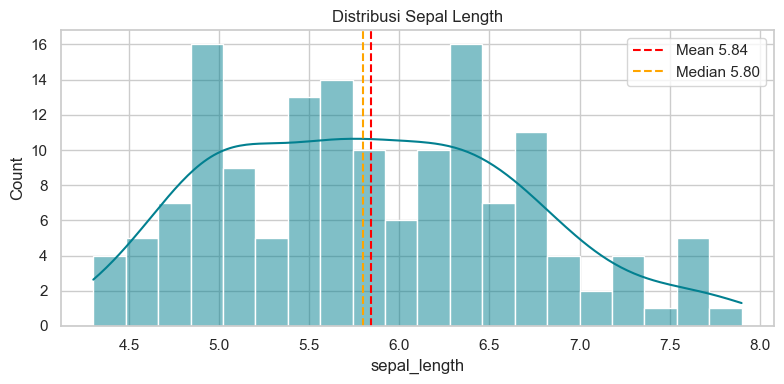

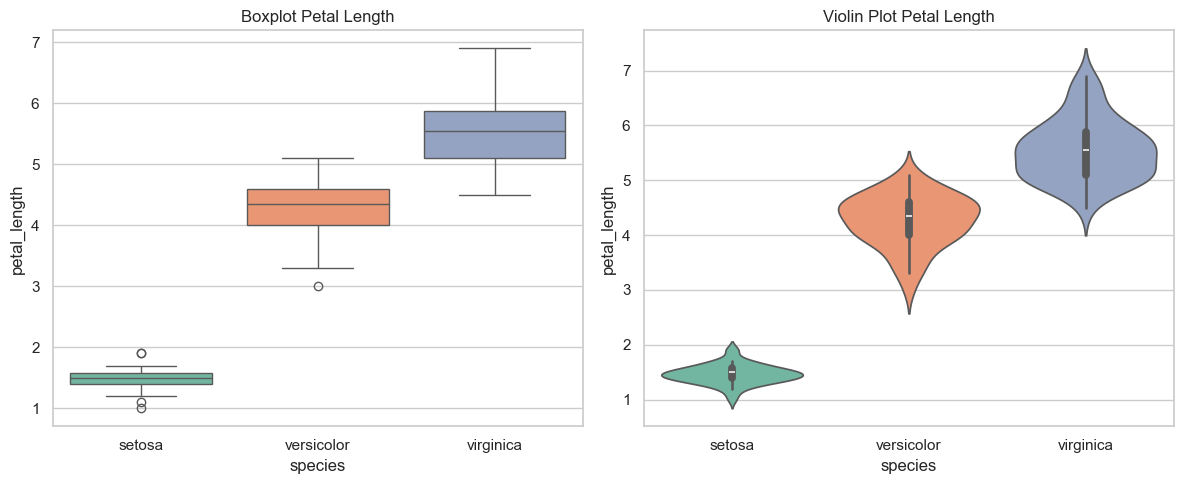

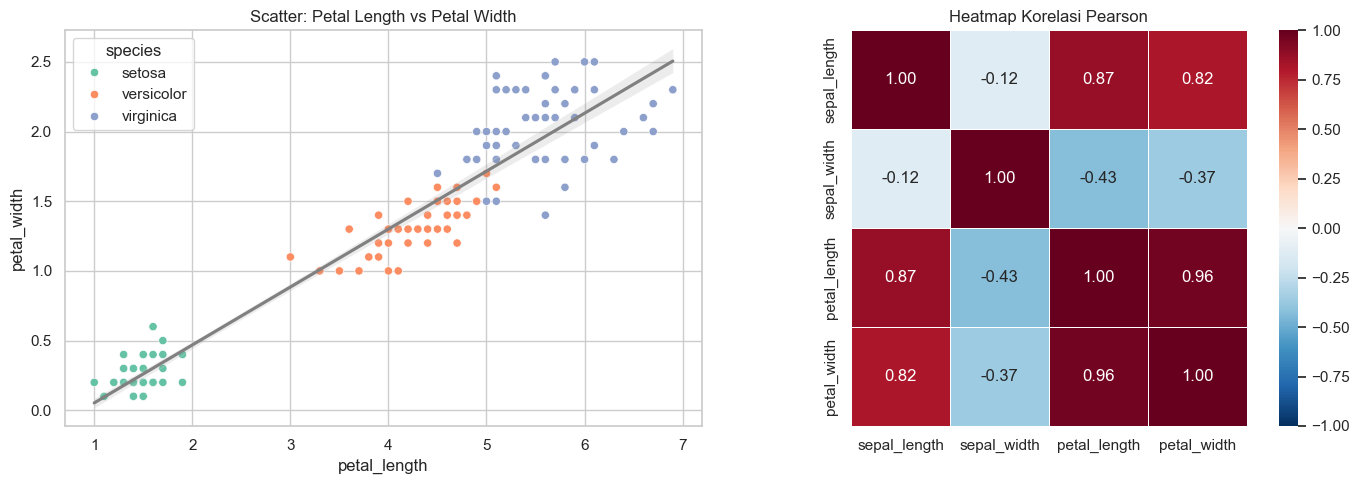

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Langkah 1: Load dataset
iris = load_iris(as_frame=True)
df = iris.frame.rename(columns={"target": "species_id"})
df["species"] = df["species_id"].map(dict(enumerate(iris.target_names)))
df = df.drop(columns="species_id")
df = df.rename(columns={
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)": "petal_width",
})

print("Shape:", df.shape)
print(df.dtypes)
print(df.head())
print(df.describe().round(3))

# Langkah 2: Statistik deskriptif lengkap
for colname in df.select_dtypes(include="number").columns:
    col = df[colname]
    print()
    print(colname)
    print("Mean    :", round(col.mean(), 3))
    print("Median  :", round(col.median(), 3))
    print("Std Dev :", round(col.std(), 3))
    print("Var     :", round(col.var(), 3))
    print("Skewness:", round(col.skew(), 3))
    print("Kurtosis:", round(col.kurt(), 3))

sns.set_theme(style="whitegrid", palette="Set2")

# Langkah 3: Distribusi sepal_length
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["sepal_length"], kde=True, color="#028090", bins=20, ax=ax)
ax.axvline(df["sepal_length"].mean(), color="red", linestyle="--", label=f"Mean {df['sepal_length'].mean():.2f}")
ax.axvline(df["sepal_length"].median(), color="orange", linestyle="--", label=f"Median {df['sepal_length'].median():.2f}")
ax.set_title("Distribusi Sepal Length")
ax.legend()
plt.tight_layout()
plt.show()

# Langkah 4: Boxplot dan violin plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="species", y="petal_length", hue="species", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Boxplot Petal Length")
sns.violinplot(data=df, x="species", y="petal_length", hue="species", palette="Set2", inner="box", legend=False, ax=axes[1])
axes[1].set_title("Violin Plot Petal Length")
plt.tight_layout()
plt.show()

# Langkah 5: Korelasi Pearson
corr = df.drop("species", axis=1).corr(method="pearson")
print()
print("Matriks korelasi Pearson:")
print(corr.round(3))
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
corr_masked = corr.where(mask)
max_pair = corr_masked.stack().idxmax()
print()
print("Korelasi tertinggi:", max_pair, "=", round(corr.loc[max_pair[0], max_pair[1]], 3))

# Langkah 6: Scatter plot dan heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species", palette="Set2", ax=axes[0])
sns.regplot(data=df, x="petal_length", y="petal_width", scatter=False, color="gray", ax=axes[0])
axes[0].set_title("Scatter: Petal Length vs Petal Width")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, linewidths=0.5, linecolor="white", ax=axes[1])
axes[1].set_title("Heatmap Korelasi Pearson")
plt.tight_layout()
plt.show()


## Kesimpulan

Pada pertemuan ini saya mempelajari statistik deskriptif dan visualisasi untuk memahami karakteristik dataset Iris. Korelasi tertinggi terlihat pada hubungan panjang dan lebar petal, sehingga fitur petal sangat membantu membedakan spesies. Keterbatasannya adalah dataset Iris relatif bersih dan kecil, sehingga belum menunjukkan tantangan data nyata yang lebih kompleks.